# WESM Price Prediction - Model 2: Polynomial Ridge Regression

## Setup and Loading

This notebook trains a Polynomial Ridge Regression model as the second model for predicting Luzon GWAP from WESM market features.

### Why this model?

Model 1 (Linear Regression) failed badly at the extremes. The RMSE for negative GWAP intervals was ₱2,209 and for intervals above ₱10,000/MWh it reached ₱6,264. These were consistent failures, not random noise, and the likely cause is underfitting since a straight line cannot capture what happens at market extremes.

**Polynomial features** give the model more flexibility by adding squared terms and interaction terms. For example, the model can now learn that high demand is much worse when there are also a lot of outages, which a linear model cannot express.

**Ridge regularization** is needed because expanding 16 features to degree 2 produces 152 features. With that many features, the model can easily overfit if left unconstrained. Ridge keeps the coefficients in check without discarding any of the polynomial terms, and `alpha` is tuned on the validation set.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(df.head())

Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00
             datetime       GWAP  energy_demand_mw  energy_supply_mw  \
0 2025-10-29 00:05:00  2258.5866           9504.45           9705.25   
1 2025-10-29 00:10:00  2913.4257           9483.49           9648.89   
2 2025-10-29 00:15:00  2883.5764           9434.35           9627.98   
3 2025-10-29 00:20:00  2888.6233           9417.62           9614.19   
4 2025-10-29 00:25:00  2887.9553           9379.48           9575.17   

   energy_shortage_mw  reserve_demand_mw  reserve_supply_mw  outage_count  \
0             -200.80             1428.0             1428.0           4.0   
1             -165.40             1428.0             1428.0           4.0   
2             -193.63             1428.0             1428.0           4.0   
3             -196.57             1428.0             1428.0           4.0   
4             -195.69             1428.0             1428.0           4.0   

   GWAP_Lag_1  GWAP_La

---

## I. Feature Selection

The same 16 base features as Model 1 are used, for the same reasons. Refer to Notebook 3 for the full feature justification table.

**Note:** `energy_shortage_mw` remains excluded for the same perfect multicollinearity reason.

In [28]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Number of base features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of base features: 16
Features: ['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


---

## II. Train / Validation / Test Split

The same chronological 60/20/20 split as Model 1 is used. The validation set plays an active role here since it is used to select the best `alpha` before the final model is retrained on train+val. A 20% validation window (Jan 8 - Feb 1) gives a more stable and representative signal for the alpha search compared to a narrower slice.

Chronological splitting is especially important here because the polynomial features include lag interactions (e.g., `GWAP_Lag_1 x GWAP_Lag_12`). A random split would allow future-to-past information leakage through these interaction terms.

In [29]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  20721 rows | 2025-10-29 to 2026-01-08
Val   :   6907 rows | 2026-01-08 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


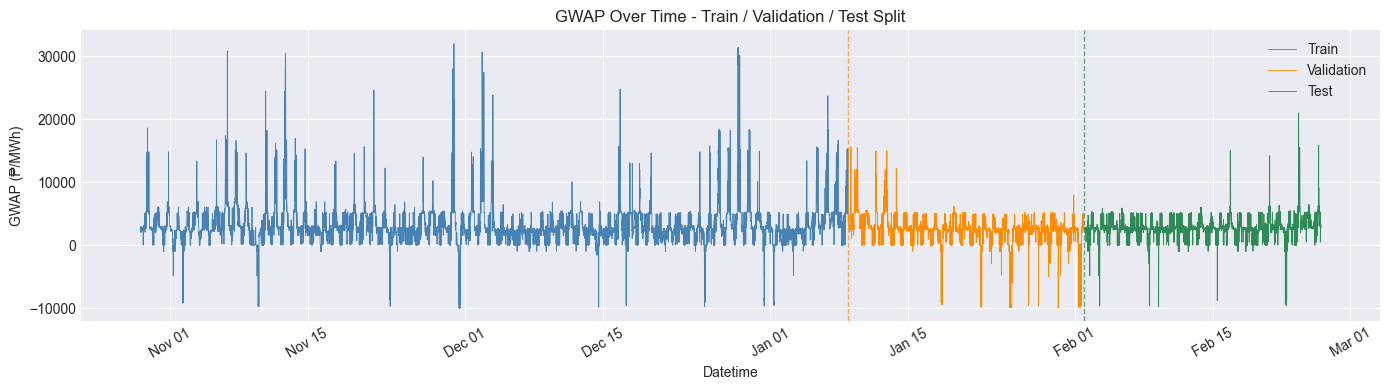

In [30]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("GWAP Over Time - Train / Validation / Test Split")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [31]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

---

## III. Feature Scaling

Same standardization approach as Model 1, with one important difference: **scaling is applied before polynomial expansion**, not after. If we expand first, the squared terms (e.g., `GWAP_Lag_1²`) would reach into the billions on the raw scale, making the Ridge penalty ineffective. Scaling first ensures all polynomial terms are derived from standardized inputs.

The scaler is **fit only on the training set** and applied to validation and test to avoid data leakage.

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train mean (before poly): {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"Train std  (before poly): {X_train_scaled.std(axis=0).mean():.6f}")

Train mean (before poly): -0.000000
Train std  (before poly): 1.000000


---

## IV. Polynomial Feature Expansion

`PolynomialFeatures` from scikit-learn generates all polynomial and interaction terms for us. For degree 2 with 16 features, this produces 16 original features, 16 squared terms (e.g., `GWAP_Lag_1²`), and 120 pairwise interaction terms (e.g., `GWAP_Lag_1 x energy_demand_mw`). We end up with a **total of 152 features** (with `include_bias=False` since Ridge already does that with `fit_intercept=True`).

We only go up to degree 2 for two reasons. First, degree 3 would produce over 900 features and that would most likely make our model overfit. Second, degree 2 already covers the most economically meaningful non-linear patterns: whether a feature amplifies its own effect at extreme values (squared terms) and whether two features interact with each other (cross terms). Going higher adds too much complexity without a clear economic justification.

The `PolynomialFeatures` transformer is **fit on training data only**. Validation and test are then transformed using the same structure.

In [33]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly   = poly.transform(X_val_scaled)
X_test_poly  = poly.transform(X_test_scaled)

feature_names = poly.get_feature_names_out(FEATURE_COLS)

print(f"Original features  : {X_train_scaled.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")
print(f"\nSample of generated feature names:")
print(feature_names[:10].tolist())
print("...")
print(feature_names[-5:].tolist())

Original features  : 16
Polynomial features: 152

Sample of generated feature names:
['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos']
...
['dow_4 dow_5', 'dow_4 dow_6', 'dow_5^2', 'dow_5 dow_6', 'dow_6^2']


---

## V. Hyperparameter Tuning

Ridge has one hyperparameter: `alpha`, which controls the strength of the L2 regularization. Higher alpha means stronger shrinkage; too high and the model collapses back toward linear by ignoring most polynomial terms.

Following the coarse-to-fine search from the Tips and Tricks lecture, we first sweep a wide range to find the general neighborhood of the best alpha, then zoom in with a finer grid to pin down the exact value.

In [34]:
alphas_coarse = np.logspace(-2, 6, 50)
val_rmses_coarse = []

for alpha in alphas_coarse:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    y_val_pred = model.predict(X_val_poly)
    val_rmses_coarse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

best_idx_coarse = np.argmin(val_rmses_coarse)
best_alpha_coarse = alphas_coarse[best_idx_coarse]
print(f"Coarse best alpha : {best_alpha_coarse:.4f}  (val RMSE: {val_rmses_coarse[best_idx_coarse]:.4f})")

Coarse best alpha : 255.9548  (val RMSE: 1085.4649)


In [35]:
alphas_fine = np.logspace(
    np.log10(best_alpha_coarse) - 1,
    np.log10(best_alpha_coarse) + 1,
    100
)
val_rmses_fine = []

for alpha in alphas_fine:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    y_val_pred = model.predict(X_val_poly)
    val_rmses_fine.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

best_idx_fine = np.argmin(val_rmses_fine)
best_alpha = alphas_fine[best_idx_fine]
print(f"Fine best alpha   : {best_alpha:.4f}  (val RMSE: {val_rmses_fine[best_idx_fine]:.4f})")

Fine best alpha   : 250.0704  (val RMSE: 1085.4653)


The plot below shows validation RMSE across the fine alpha search. There is a clear minimum at alpha ≈ 250.1, confirming that regularization is needed when working with 152 polynomial features.

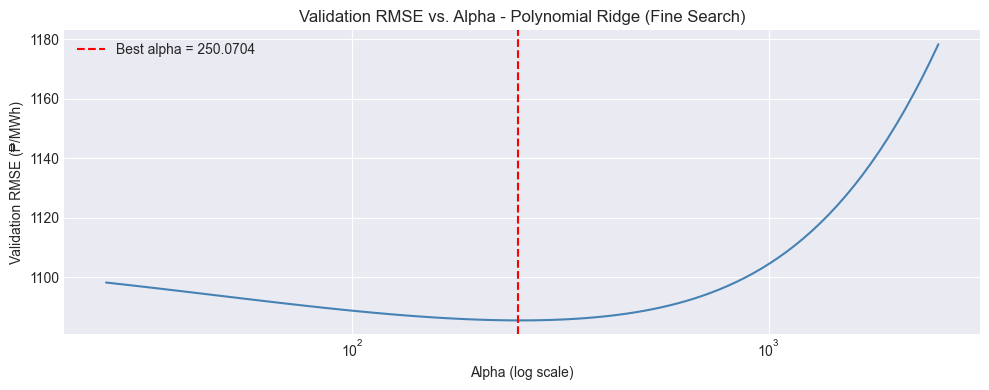

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(alphas_fine, val_rmses_fine, color="steelblue", linewidth=1.5)
ax.axvline(best_alpha, color="red", linestyle="--", linewidth=1.5, label=f"Best alpha = {best_alpha:.4f}")
ax.set_xscale("log")
ax.set_title("Validation RMSE vs. Alpha - Polynomial Ridge (Fine Search)")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Validation RMSE (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

---

## VI. Model Training

Same two-model process as Model 1:

1. **`ridge_poly`** - trained on the training set only using the best alpha. Used to evaluate train and validation performance.
2. **`ridge_poly_final`** - retrained on the combined train + validation set using the same best alpha. This is the model used for final test evaluation.

In [37]:
# Selection-phase model (train only)
ridge_poly = Ridge(alpha=best_alpha)
ridge_poly.fit(X_train_poly, y_train)

# Refit scaler on train+val for the final model
scaler_final = StandardScaler()
X_trainval_raw = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

X_trainval_scaled_final = scaler_final.fit_transform(X_trainval_raw)
X_test_scaled_final     = scaler_final.transform(X_test)

X_trainval_poly = poly.transform(X_trainval_scaled_final)
X_test_poly_final = poly.transform(X_test_scaled_final)

ridge_poly_final = Ridge(alpha=best_alpha)
ridge_poly_final.fit(X_trainval_poly, y_trainval)

print(f"Best alpha : {best_alpha:.4f}")
print(f"ridge_poly       intercept (train only)  : {ridge_poly.intercept_:.4f}")
print(f"ridge_poly_final intercept (train + val) : {ridge_poly_final.intercept_:.4f}")

Best alpha : 250.0704
ridge_poly       intercept (train only)  : 3179.2032
ridge_poly_final intercept (train + val) : 3045.1195


---

## VII. Evaluation

Same evaluation protocol as Model 1. Train and validation are evaluated using `ridge_poly`. Train+Val and Test are evaluated using `ridge_poly_final`.

In [38]:
def evaluate(model, X, y, label):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    print(f"{label:<12} | RMSE: {rmse:>10.4f} | MAE: {mae:>10.4f} | R²: {r2:>8.4f}")
    return y_pred, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>16} | {'MAE':>15} | {'R²':>12}")
print("-" * 68)
y_train_pred,    train_rmse,    train_mae,    train_r2    = evaluate(ridge_poly,       X_train_poly,    y_train,    "Train")
y_val_pred,      val_rmse,      val_mae,      val_r2      = evaluate(ridge_poly,       X_val_poly,      y_val,      "Validation")
y_trainval_pred, trainval_rmse, _,            _           = evaluate(ridge_poly_final, X_trainval_poly, y_trainval, "Train+Val")
y_test_pred,     test_rmse,     test_mae,     test_r2     = evaluate(ridge_poly_final, X_test_poly_final, y_test,   "Test")

Split        |             RMSE |             MAE |           R²
--------------------------------------------------------------------
Train        | RMSE:  1201.1785 | MAE:   592.3613 | R²:   0.8306
Validation   | RMSE:  1085.4653 | MAE:   570.4261 | R²:   0.8010
Train+Val    | RMSE:  1161.0450 | MAE:   568.4361 | R²:   0.8317
Test         | RMSE:   967.5797 | MAE:   545.9429 | R²:   0.6477


### Bias-Variance Diagnosis

Same framework as Model 1. `ridge_poly` is compared against its train RMSE for the val gap and `ridge_poly_final` is compared against its train+val RMSE for the test gap.

Both are negative, so the model is not overfitting. However, the general performance is worse than the linear baseline, which means the polynomial terms are adding noise rather than predictive value.

In [39]:
gap_val  = val_rmse - train_rmse
gap_test = test_rmse - trainval_rmse

print(f"Val  - Train gap     : {gap_val:.4f}  ({gap_val / train_rmse * 100:.1f}% of train RMSE)")
print(f"Test - Train+Val gap : {gap_test:.4f}  ({gap_test / trainval_rmse * 100:.1f}% of train+val RMSE)")

Val  - Train gap     : -115.7132  (-9.6% of train RMSE)
Test - Train+Val gap : -193.4653  (-16.7% of train+val RMSE)


### Comparison with Model 1 (Linear Regression)

The table below compares test performance directly.

In [40]:
lr_test_rmse = 934.4698
lr_test_mae  = 459.4758
lr_test_r2   = 0.6714

comparison = pd.DataFrame({
    "Model"    : ["Linear Regression (baseline)", "Polynomial Ridge (degree=2)"],
    "Test RMSE": [lr_test_rmse, test_rmse],
    "Test MAE" : [lr_test_mae,  test_mae],
    "Test R²"  : [lr_test_r2,   test_r2]
})

print(comparison.to_string(index=False))
print()
print(f"RMSE improvement over baseline : {lr_test_rmse - test_rmse:.4f} ₱/MWh  ({(lr_test_rmse - test_rmse) / lr_test_rmse * 100:.2f}%)")

                       Model  Test RMSE   Test MAE  Test R²
Linear Regression (baseline) 934.469800 459.475800 0.671400
 Polynomial Ridge (degree=2) 967.579745 545.942893 0.647729

RMSE improvement over baseline : -33.1099 ₱/MWh  (-3.54%)


Polynomial Ridge performs worse than the linear baseline on all three metrics: test RMSE increased from ₱934 to ₱972 (+4.0%), MAE from ₱459 to ₱553, and R² dropped from 0.671 to 0.644.

This is counterintuitive given that polynomial features were motivated by underfitting. The explanation is that many of the 152 interaction terms (e.g., `dow_1 x dow_2`, `hour_sin x hour_cos`) have no economic meaning. Ridge shrinks them toward zero but cannot eliminate them, and the cumulative noise degrades performance in the normal price range.

---

## VIII. Visualizations

### Actual vs. Predicted (Time Series)

Same two-panel layout as Model 1. Since Polynomial Ridge performs worse overall, the predictions in the test period track the actual values less closely, particularly in the moderate price range where Model 1 was already performing well.

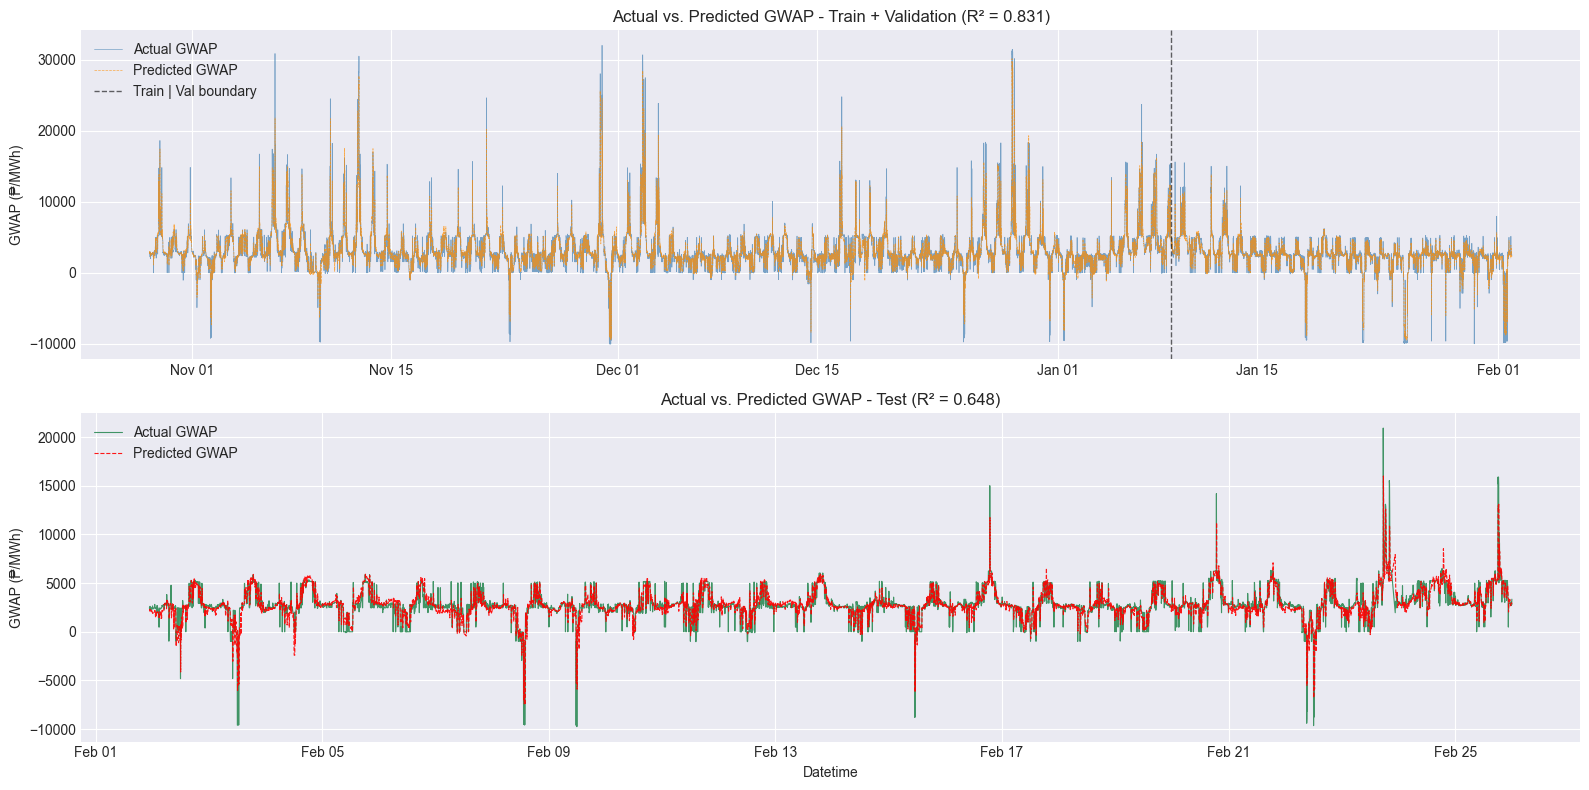

Train+Val GWAP std : 2830.47
Test GWAP std      : 1630.35


In [41]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Train+Val
axes[0].plot(train_df["datetime"].values, y_train.values, color="steelblue", linewidth=0.5, alpha=0.7, label="Actual GWAP")
axes[0].plot(val_df["datetime"].values,   y_val.values,   color="steelblue", linewidth=0.5, alpha=0.7)
axes[0].plot(train_df["datetime"].values, ridge_poly_final.predict(poly.transform(scaler_final.transform(X_train))), color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--", label="Predicted GWAP")
axes[0].plot(val_df["datetime"].values,   ridge_poly_final.predict(poly.transform(scaler_final.transform(X_val))),   color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--")
axes[0].axvline(val_df["datetime"].min(), color="black", linestyle="--", linewidth=1, alpha=0.6, label="Train | Val boundary")
axes[0].set_title(f"Actual vs. Predicted GWAP - Train + Validation (R² = {round(train_r2, 3)})")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].legend(loc="upper left")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Test
axes[1].plot(test_df["datetime"].values, y_test.values, color="seagreen", linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[1].plot(test_df["datetime"].values, y_test_pred,   color="red",      linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[1].set_title(f"Actual vs. Predicted GWAP - Test (R² = {round(test_r2, 3)})")
axes[1].set_ylabel("GWAP (₱/MWh)")
axes[1].set_xlabel("Datetime")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

print(f"Train+Val GWAP std : {y_trainval.std():.2f}")
print(f"Test GWAP std      : {y_test.std():.2f}")

### Actual vs. Predicted - Scatter Plot

Same as Model 1. Since performance is worse overall, the extreme points are not really closer to the diagonal.

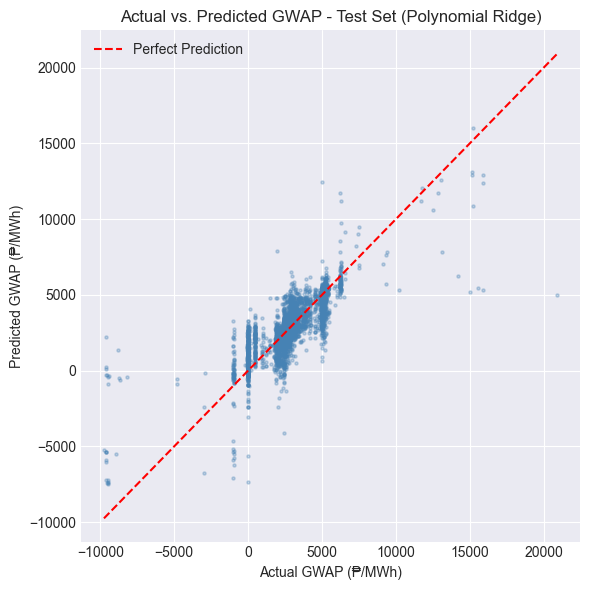

In [42]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_test_pred, alpha=0.3, s=5, color="steelblue")

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted GWAP - Test Set (Polynomial Ridge)")
ax.set_xlabel("Actual GWAP (₱/MWh)")
ax.set_ylabel("Predicted GWAP (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Plot

Residuals here are just the difference between actual and predicted GWAP (actual - predicted).

Since Polynomial Ridge underperforms the linear baseline, we expect the spread to be wider than Model 1.

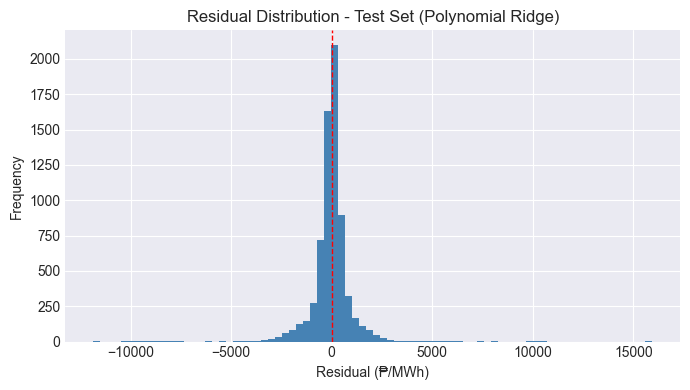

Mean Residual : -19.8494  (close to 0 = unbiased)
Std Residual  : 967.3761
Max Residual  : 15928.6811
Min Residual  : -11852.1101


In [43]:
residuals_test = y_test.values - y_test_pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(residuals_test, bins=80, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution - Test Set (Polynomial Ridge)")
ax.set_xlabel("Residual (₱/MWh)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals_test.mean():.4f}  (close to 0 = unbiased)")
print(f"Std Residual  : {residuals_test.std():.4f}")
print(f"Max Residual  : {residuals_test.max():.4f}")
print(f"Min Residual  : {residuals_test.min():.4f}")

The distribution is consistent with the evaluation metrics: not systematically biased (mean near zero) but with a wider spread than Model 1. The polynomial terms are adding variance without capturing the spike-related failures any better.

---

## IX. Feature Coefficients

With 152 features, we focus on the **top 20 by absolute magnitude** from `ridge_poly_final`. Features with no `^2` or space in the name are original features also present in Model 1; the rest are polynomial or interaction terms.

In [44]:
coef_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": ridge_poly_final.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

top20 = coef_df.head(20)
print("Top 20 features by absolute coefficient:")
print(top20.to_string(index=False))

n_original = sum(1 for f in top20["Feature"] if " " not in f and "^" not in f)
n_poly     = len(top20) - n_original
print(f"\nOriginal features in top 20 : {n_original}")
print(f"Polynomial/interaction terms : {n_poly}")

Top 20 features by absolute coefficient:
                      Feature  Coefficient
                   GWAP_Lag_1  1858.514710
                  GWAP_Lag_12   399.436357
          GWAP_Lag_1 hour_cos  -325.809923
                 GWAP_Lag_288   312.825318
          GWAP_Lag_1 hour_sin  -227.796499
             energy_demand_mw   202.012452
           energy_demand_mw^2   178.088610
         GWAP_Lag_12 hour_sin   160.764330
energy_demand_mw GWAP_Lag_288   146.564949
         GWAP_Lag_12 hour_cos   142.782705
           energy_supply_mw^2  -129.231879
energy_supply_mw GWAP_Lag_288  -118.246806
            hour_sin hour_cos   108.889279
 energy_demand_mw GWAP_Lag_12    89.610966
      outage_count GWAP_Lag_1   -84.763500
           GWAP_Lag_288 dow_2    83.618470
           GWAP_Lag_288 dow_3    80.549810
        GWAP_Lag_288 hour_sin    79.238588
    outage_count GWAP_Lag_288    77.479573
             GWAP_Lag_1 dow_6    76.885411

Original features in top 20 : 4
Polynomial/interaction 

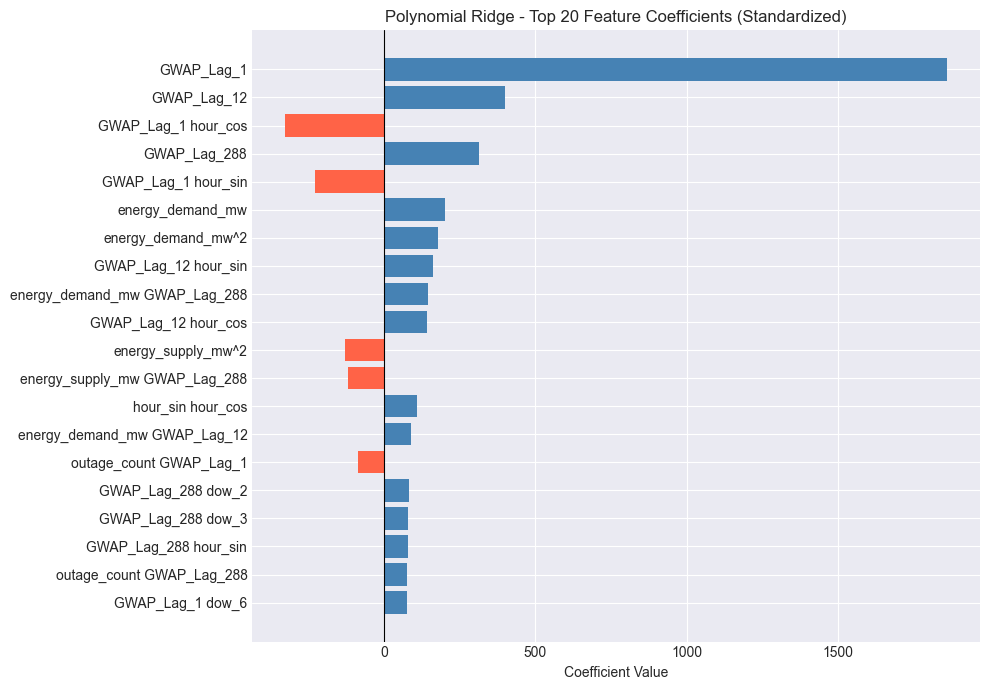

In [45]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["steelblue" if c >= 0 else "tomato" for c in top20["Coefficient"]]
ax.barh(top20["Feature"], top20["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Polynomial Ridge - Top 20 Feature Coefficients (Standardized)")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The three lag features remain dominant, consistent with Model 1. Also, 15 of the top 20 features are polynomial or interaction terms, confirming the model is using the expanded features.

The polynomial terms in the top 20 are primarily lag-hour interactions (e.g., `GWAP_Lag_1 hour_cos`, `GWAP_Lag_1 hour_sin`) and energy-lag interactions, which have plausible economic interpretations. Despite this, the overall model performance is worse. TThus, these interactions are not strong enough to compensate for the noise from the many economically meaningless terms that Ridge cannot shrink to exactly zero.

---

## X. Error Analysis

Same segmentation as Model 1. The key question is whether polynomial features reduce errors at the extremes (Negative GWAP and >₱10,000) where Model 1 struggled most.

In [46]:
error_df = test_df[["datetime", "GWAP"]].copy()
error_df["predicted"] = y_test_pred
error_df["residual"]  = error_df["GWAP"] - error_df["predicted"]
error_df["abs_error"] = error_df["residual"].abs()

bins   = [-10000, 0, 2000, 5000, 10000, 35000]
labels = ["Negative", "0-2k", "2k-5k", "5k-10k", ">10k"]
error_df["gwap_segment"] = pd.cut(error_df["GWAP"], bins=bins, labels=labels)

segment_summary = error_df.groupby("gwap_segment", observed=True).agg(
    count     = ("GWAP", "count"),
    mean_gwap = ("GWAP", "mean"),
    rmse      = ("residual", lambda x: np.sqrt((x**2).mean())),
    mae       = ("abs_error", "mean")
).reset_index()

lr_segment_rmses = [2208.886686, 1220.638104, 562.212687, 1014.637240, 6264.010822]
segment_summary["LR RMSE"] = lr_segment_rmses
segment_summary["RMSE improvement"] = segment_summary["LR RMSE"] - segment_summary["rmse"]

print(segment_summary.to_string(index=False))

gwap_segment  count    mean_gwap        rmse         mae     LR RMSE  RMSE improvement
    Negative    459  -695.253988 2215.571149 1432.947766 2208.886686         -6.684463
        0-2k    411  1084.738367 1259.646042  972.371889 1220.638104        -39.007938
       2k-5k   5219  2806.565112  631.652781  409.830456  562.212687        -69.440094
      5k-10k    800  5302.908570  965.028957  612.404522 1014.637240         49.608283
        >10k     18 14405.645722 6384.973110 4701.718296 6264.010822       -120.962288


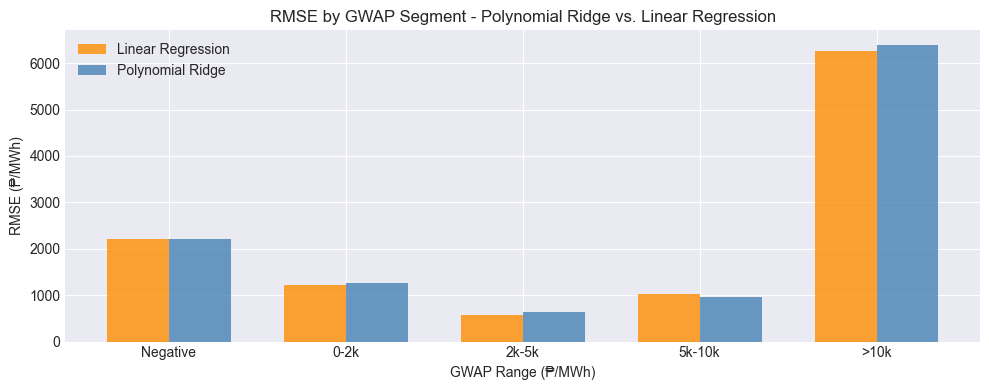

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(segment_summary))
width = 0.35

ax.bar(x - width/2, segment_summary["LR RMSE"], width, label="Linear Regression", color="darkorange", alpha=0.8)
ax.bar(x + width/2, segment_summary["rmse"],    width, label="Polynomial Ridge",  color="steelblue",  alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(segment_summary["gwap_segment"].astype(str))
ax.set_title("RMSE by GWAP Segment - Polynomial Ridge vs. Linear Regression")
ax.set_xlabel("GWAP Range (₱/MWh)")
ax.set_ylabel("RMSE (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

Polynomial Ridge actually improves on the ₱5,000-₱10,000 range (RMSE drops from ₱1,015 to ₱965), suggesting some lag-hour interaction terms do capture moderate-to-high price dynamics. However, it performs worse in every other segment including the dominant ₱2,000-₱5,000 range (RMSE increases from ₱562 to ₱634), which accounts for 75.6% of test intervals. The net effect is a higher overall RMSE.

---

## XII. Bonus: Polynomial Elastic Net

Elastic Net combines both L1 (Lasso) and L2 (Ridge) penalties. The L1 component is what makes it potentially more useful here: unlike Ridge which can only shrink coefficients toward zero, Lasso can set them to exactly zero and eliminate features entirely. With 152 features where many are likely just noise, that matters.

There are two hyperparameters to tune. `alpha` controls the overall regularization strength, same as before. `l1_ratio` controls the mix between L1 and L2: at 0 it is pure Ridge, at 1.0 it is pure Lasso, and values in between are a blend. We search over `[0.1, 0.3, 0.5, 0.7, 0.9, 1.0]` to keep it simple. This is enough since there are only a handful of values to try, unlike alpha which needs the coarse-to-fine treatment.

In [ ]:
from sklearn.linear_model import ElasticNet

alphas_en    = np.logspace(0, 5, 20)
l1_ratios_en = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

best_en_rmse  = np.inf
best_en_alpha = None
best_l1_ratio = None

for alpha in alphas_en:
    for l1_ratio in l1_ratios_en:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, tol=1e-3)
        model.fit(X_train_poly, y_train)
        y_val_pred_en = model.predict(X_val_poly)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_en))
        if rmse < best_en_rmse:
            best_en_rmse  = rmse
            best_en_alpha = alpha
            best_l1_ratio = l1_ratio

print(f"Best alpha    : {best_en_alpha:.6f}")
print(f"Best l1_ratio : {best_l1_ratio}")
print(f"Best val RMSE : {best_en_rmse:.4f}")

In [ ]:
en_poly = ElasticNet(alpha=best_en_alpha, l1_ratio=best_l1_ratio, max_iter=5000, tol=1e-3)
en_poly.fit(X_train_poly, y_train)

en_poly_final = ElasticNet(alpha=best_en_alpha, l1_ratio=best_l1_ratio, max_iter=5000, tol=1e-3)
en_poly_final.fit(X_trainval_poly, y_trainval)

print(f"en_poly       intercept (train only)  : {en_poly.intercept_:.4f}")
print(f"en_poly_final intercept (train + val) : {en_poly_final.intercept_:.4f}")

en_poly       intercept (train only)  : 3214.1444
en_poly_final intercept (train + val) : 3021.0119


In [ ]:
print(f"{'Split':<12} | {'RMSE':>16} | {'MAE':>15} | {'R²':>12}")
print("-" * 68)
y_en_train_pred,    en_train_rmse,    en_train_mae,    en_train_r2    = evaluate(en_poly,       X_train_poly,    y_train,    "Train")
y_en_val_pred,      en_val_rmse,      en_val_mae,      en_val_r2      = evaluate(en_poly,       X_val_poly,      y_val,      "Validation")
y_en_trainval_pred, en_trainval_rmse, _,               _              = evaluate(en_poly_final, X_trainval_poly, y_trainval, "Train+Val")
y_en_test_pred,     en_test_rmse,     en_test_mae,     en_test_r2     = evaluate(en_poly_final, X_test_poly_final, y_test,   "Test")

Split        |             RMSE |             MAE |           R²
--------------------------------------------------------------------
Train        | RMSE:  1221.6429 | MAE:   574.1059 | R²:   0.8248
Validation   | RMSE:  1038.8133 | MAE:   493.0458 | R²:   0.8177
Train+Val    | RMSE:  1179.7952 | MAE:   555.5462 | R²:   0.8263
Test         | RMSE:   930.4221 | MAE:   462.7226 | R²:   0.6743


In [ ]:
zeroed_out = (en_poly_final.coef_ == 0).sum()
print(f"Total polynomial features : {len(en_poly_final.coef_)}")
print(f"Features zeroed out by Elastic Net: {zeroed_out} ({zeroed_out / len(en_poly_final.coef_) * 100:.1f}%)")

# Top 20 non-zero coefficients
en_coef_df = pd.DataFrame({
    "Feature"         : feature_names,
    "ElasticNet Coef" : en_poly_final.coef_,
    "Ridge Coef"      : ridge_poly_final.coef_
}).sort_values("ElasticNet Coef", key=abs, ascending=False)

print("\nTop 20 by absolute ElasticNet coefficient:")
print(en_coef_df.head(20).to_string(index=False))

Total polynomial features : 152
Features zeroed out by Elastic Net: 124 (81.6%)

Top 20 by absolute ElasticNet coefficient:
                  Feature  ElasticNet Coef  Ridge Coef
               GWAP_Lag_1      2047.601605 1858.514710
              GWAP_Lag_12       320.187107  399.436357
             GWAP_Lag_288       203.764589  312.825318
      GWAP_Lag_1 hour_cos      -156.910446 -325.809923
         energy_demand_mw        62.512472  202.012452
 GWAP_Lag_12 GWAP_Lag_288        48.665737   71.303596
      GWAP_Lag_1 hour_sin       -37.806832 -227.796499
        hour_sin hour_cos        36.077034  108.889279
        reserve_demand_mw        31.694056   23.622175
                 hour_sin       -27.527642   -4.326368
         GWAP_Lag_1 dow_6        27.238249   76.885411
outage_count GWAP_Lag_288        27.009163   77.479573
            GWAP_Lag_12^2       -20.568394  -28.386685
             GWAP_Lag_1^2        17.675355   12.552945
  outage_count GWAP_Lag_1       -15.584984  -84.763

In [ ]:
final_comparison = pd.DataFrame({
    "Model"    : ["Linear Regression", "Polynomial Ridge", "Polynomial Elastic Net"],
    "Test RMSE": [lr_test_rmse, test_rmse,    en_test_rmse],
    "Test MAE" : [lr_test_mae,  test_mae,     en_test_mae],
    "Test R²"  : [lr_test_r2,   test_r2,      en_test_r2]
})

print(final_comparison.to_string(index=False))

                 Model  Test RMSE   Test MAE  Test R²
     Linear Regression 934.469800 459.475800 0.671400
      Polynomial Ridge 967.579745 545.942893 0.647729
Polynomial Elastic Net 930.422138 462.722610 0.674266
